In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model
model_nasser=load_model('/content/drive/MyDrive/Colab Notebooks/Final_model/for10epoch_tuned_1.h5')

In [ ]:
!wget http://www.inf.ufpr.br/vri/databases/PKLot.tar.gz

--2023-05-25 10:09:22--  http://www.inf.ufpr.br/vri/databases/PKLot.tar.gz
Resolving www.inf.ufpr.br (www.inf.ufpr.br)... 200.17.202.113, 2801:82:80ff:8001:216:ccff:feaa:79
Connecting to www.inf.ufpr.br (www.inf.ufpr.br)|200.17.202.113|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.inf.ufpr.br/vri/databases/PKLot.tar.gz [following]
--2023-05-25 10:09:24--  https://www.inf.ufpr.br/vri/databases/PKLot.tar.gz
Connecting to www.inf.ufpr.br (www.inf.ufpr.br)|200.17.202.113|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4898276304 (4.6G) [application/octet-stream]
Saving to: ‘PKLot.tar.gz’

PKLot.tar.gz        100%[===================>]   4.56G  9.31MB/s    in 8m 46s  

2023-05-25 10:18:12 (8.88 MB/s) - ‘PKLot.tar.gz’ saved [4898276304/4898276304]



In [ ]:
!tar xvzf  /content/PKLot.tar.gz

Streaming output truncated to the last 5000 lines.
PKLot/PKLotSegmented/PUC/Sunny/2012-09-20/Occupied/2012-09-20_18_09_45#088.jpg
PKLot/PKLotSegmented/PUC/Cloudy/2012-09-28/Occupied/2012-09-28_09_06_05#086.jpg
PKLot/PKLotSegmented/PUC/Cloudy/2012-10-31/Occupied/2012-10-31_14_33_21#092.jpg
PKLot/PKLotSegmented/UFPR04/Rainy/2013-01-21/Occupied/2013-01-21_08_35_04#011.jpg
PKLot/PKLotSegmented/PUC/Cloudy/2012-10-16/Empty/2012-10-16_06_26_44#050.jpg
PKLot/PKLotSegmented/PUC/Cloudy/2012-09-28/Occupied/2012-09-28_11_06_11#047.jpg
PKLot/PKLotSegmented/PUC/Sunny/2012-09-17/Occupied/2012-09-17_10_59_02#100.jpg
PKLot/PKLotSegmented/UFPR05/Sunny/2013-03-10/Empty/2013-03-10_17_35_13#027.jpg
PKLot/PKLotSegmented/PUC/Sunny/2012-10-27/Empty/2012-10-27_12_15_53#018.jpg
PKLot/PKLotSegmented/PUC/Rainy/2012-09-21/Occupied/2012-09-21_11_45_24#077.jpg
PKLot/PKLotSegmented/PUC/Sunny/2012-09-20/Occupied/2012-09-20_17_34_43#052.jpg
PKLot/PKLotSegmented/UFPR05/Cloudy/2013-03-17/Empty/2013-03-17_15_20_10#033.jpg

In [ ]:
!mkdir all_lots  all_lots/train_lots  all_lots/train_lots/occupied  all_lots/train_lots/vacant
!mkdir all_lots/test_lots  all_lots/test_lots/occupied all_lots/test_lots/vacant

In [ ]:
#opereat on Empty or occupied parking space (division)
def split_data(Empty_directory_p,occupied_directory_p,path_test_vacant,path_test_occupied,path_train_vacant,path_train_occupied):
  import shutil , os
  from random import shuffle

  for empty  in Empty_directory_p:
      E=os.listdir(empty)
      shuffle(E)
      E1=round(len(E)*.80)
      empty_train=E[:E1]
      empty_test=E[E1:]

      for empty_Train_1  in empty_train:
        shutil.move(empty+'/'+empty_Train_1,path_train_vacant)
        
      for empty_test_1 in empty_test:
        shutil.move(empty+'/'+empty_test_1,path_test_vacant)

  #===================================================================================
  for occupied in occupied_directory_p:
    O=os.listdir(occupied)
    shuffle(O)
    O1=round(len(O)*.80)
    occupied_train=O[:O1]
    occupied_test=O[O1:]    

    for  occupied_train_1 in occupied_train : 
        shutil.move(occupied+'/'+occupied_train_1,path_train_occupied)

    for occupied_test_1 in occupied_test:
        shutil.move(occupied+'/'+occupied_test_1,path_test_occupied)

  #===========================================================================================



In [ ]:
#prepare pathes for data handling 
import os 
views=os.listdir('/content/PKLot/PKLotSegmented')
weathers=os.listdir('/content/PKLot/PKLotSegmented/PUC')

#===========================================================
directorys=[]
for view in views:
  for weather in weathers:
    directorys.append(os.path.join(view,weather))
%cd /content/PKLot/PKLotSegmented


Empty_directory=[]
Occupied_directory=[]
#==================================================================
for dir in directorys:
  temp_list=os.listdir(dir)
  for temp in temp_list:
    two_class=os.listdir(dir+'/'+temp)
    if len(two_class)==2:
      Empty_directory.append(os.path.join(dir,temp+'/Empty'))
      Occupied_directory.append(os.path.join(dir,temp+'/Occupied'))
    elif two_class[0]=='Empty':
      Empty_directory.append(os.path.join(dir,temp+'/Empty'))
    elif two_class[0]=='Occupied':
      Occupied_directory.append(os.path.join(dir,temp+'/Occupied'))

#======================================================================
#REMOVE TWO DIRECTORY THAT CONTAIN SINGLITON PHOTO
Empty_directory.remove('UFPR05/Rainy/2013-02-26/Empty')
Occupied_directory.remove('UFPR04/Rainy/2012-12-15/Occupied')
#=======================================================================

split_data(Empty_directory,Occupied_directory,'/content/all_lots/test_lots/vacant','/content/all_lots/test_lots/occupied',
           '/content/all_lots/train_lots/vacant','/content/all_lots/train_lots/occupied')


/content/PKLot/PKLotSegmented


In [ ]:
!mkdir /content/train_data  /content/train_data/vacant /content/train_data/occupied

In [ ]:
def move_to_final_train_or_test_file(path_to_file_data_O,path_to_file_data_v,path_to_file_O,path_to_file_v):
  dirs_o = os.listdir(path_to_file_data_O)
  dirs_v= os.listdir(path_to_file_data_v)
  import shutil
  os.chdir(path_to_file_data_O)

  for dir in dirs_o:
      shutil.move(dir,path_to_file_O)
  
  os.chdir(path_to_file_data_v)
  for dir in dirs_v:
    shutil.move(dir,path_to_file_v)
  os.chdir('/content')


#print( len(os.listdir('/content/train_data/vacant')) + len(os.listdir('/content/train_data/occupied')) )

In [ ]:
move_to_final_train_or_test_file('/content/all_lots/train_lots/occupied','/content/all_lots/train_lots/vacant',
                         '/content/train_data/occupied','/content/train_data/vacant')

In [ ]:
print(len(os.listdir('/content/train_data/occupied'))+len(os.listdir('/content/train_data/vacant')))

556684


In [ ]:
%cd /content
#download CNR-EXT dataset and unzip it 
!wget http://claudiotest.isti.cnr.it/park-datasets/CNR-EXT/CNR-EXT-Patches-150x150.zip
!unzip /content/CNR-EXT-Patches-150x150.zip

Streaming output truncated to the last 5000 lines.
  inflating: PATCHES/OVERCAST/2015-12-19/camera8/O_2015-12-19_11.06_C08_211.jpg  
  inflating: PATCHES/OVERCAST/2015-12-19/camera8/O_2015-12-19_08.06_C08_214.jpg  
  inflating: PATCHES/OVERCAST/2015-12-19/camera8/O_2015-12-19_10.36_C08_325.jpg  
  inflating: PATCHES/OVERCAST/2015-12-19/camera8/O_2015-12-19_16.36_C08_291.jpg  
  inflating: PATCHES/OVERCAST/2015-12-19/camera8/O_2015-12-19_10.06_C08_283.jpg  
  inflating: PATCHES/OVERCAST/2015-12-19/camera8/O_2015-12-19_08.36_C08_317.jpg  
  inflating: PATCHES/OVERCAST/2015-12-19/camera8/O_2015-12-19_15.06_C08_321.jpg  
  inflating: PATCHES/OVERCAST/2015-12-19/camera8/O_2015-12-19_11.36_C08_255.jpg  
  inflating: PATCHES/OVERCAST/2015-12-19/camera8/O_2015-12-19_09.36_C08_292.jpg  
  inflating: PATCHES/OVERCAST/2015-12-19/camera8/O_2015-12-19_11.36_C08_327.jpg  
  inflating: PATCHES/OVERCAST/2015-12-19/camera8/O_2015-12-19_16.06_C08_324.jpg  
  inflating: PATCHES/OVERCAST/2015-12-19/camera

In [ ]:
!mkdir CNR-EXT
!mkdir CNR-EXT/OverCast/
!mkdir CNR-EXT/Rainy/
!mkdir CNR-EXT/Sunnay/

In [ ]:
import os
dirs=os.listdir('/content/CNR-EXT')
%cd '/content/CNR-EXT'

for dir in dirs:
  for i in range(1,10):
      inner_path=os.path.join( dir,"C-{}".format(i) )
      os.mkdir(inner_path)
      vacent_path=os.path.join(inner_path,'vacent')
      occupied_path=os.path.join(inner_path,'occupied')
      os.mkdir(vacent_path)
      os.mkdir(occupied_path)
 


/content/CNR-EXT


In [ ]:
def move_data(path_label,number_of_camera):
  import shutil
  
  ref_to_file=open(path_label,'r')

  for line in ref_to_file:
    l=line.split(" ")

    if not l[0].find('SUNNY'):
      if  int(l[1])==1:
          shutil.move(line.split(" ")[0],'/content/CNR-EXT/Sunnay/C-{}/occupied'.format(number_of_camera))
      else: 
          shutil.move(line.split(" ")[0],'/content/CNR-EXT/Sunnay/C-{}/vacent'.format(number_of_camera))
    elif not l[0].find('RAINY'):
      if int(l[1])==1:
          shutil.move(line.split(" ")[0],'/content/CNR-EXT/Rainy/C-{}/occupied'.format(number_of_camera))
      else: 
          shutil.move(line.split(" ")[0],'/content/CNR-EXT/Rainy/C-{}/vacent'.format(number_of_camera))
    else:
      if int(l[1])==1:
          shutil.move(line.split(" ")[0],'/content/CNR-EXT/OverCast/C-{}/occupied'.format(number_of_camera))
      else: 
          shutil.move(line.split(" ")[0],'/content/CNR-EXT/OverCast/C-{}/vacent'.format(number_of_camera))



In [ ]:
path_data='/content/PATCHES'

%cd '/content/PATCHES'
for i in range(1,10):
  path_label='/content/LABELS/camera{}.txt'.format(i)
  print(path_label)  
  move_data(path_label,i)


/content/PATCHES
/content/LABELS/camera1.txt
/content/LABELS/camera2.txt
/content/LABELS/camera3.txt
/content/LABELS/camera4.txt
/content/LABELS/camera5.txt
/content/LABELS/camera6.txt
/content/LABELS/camera7.txt
/content/LABELS/camera8.txt
/content/LABELS/camera9.txt


In [ ]:
%cd /content

/content


In [ ]:
!mkdir cnr-ext

In [ ]:
!mkdir cnr-ext/train cnr-ext/test
!mkdir cnr-ext/train/vacant cnr-ext/train/occupied 
!mkdir cnr-ext/test/vacant cnr-ext/test/occupied 

In [ ]:
dirs=os.listdir('/content/CNR-EXT')
%cd '/content/CNR-EXT'

Empty_directory_cnr=[]
occupied_directory_cnr=[]

for dir in dirs:
  for i in range(1,10):
      inner_path=os.path.join( dir,"C-{}".format(i) )
      vacent_path=os.path.join(inner_path,'vacent')
      occupied_path=os.path.join(inner_path,'occupied')
      Empty_directory_cnr.append('/content/CNR-EXT/'+vacent_path)
      occupied_directory_cnr.append('/content/CNR-EXT/'+occupied_path)   

/content/CNR-EXT


In [ ]:
split_data(Empty_directory_cnr,occupied_directory_cnr,'/content/cnr-ext/test/vacant','/content/cnr-ext/test/occupied',
           '/content/cnr-ext/train/vacant','/content/cnr-ext/train/occupied')

In [ ]:
move_to_final_train_or_test_file('/content/cnr-ext/train/occupied','/content/cnr-ext/train/vacant',
                         '/content/train_data/occupied','/content/train_data/vacant')

In [ ]:
print(len(os.listdir('/content/train_data/occupied'))+len(os.listdir('/content/train_data/vacant')))

672656


In [ ]:
#download CNR 
!wget http://claudiotest.isti.cnr.it/park-datasets/CNRPark/CNRPark-Patches-150x150.zip
!unzip /content/CNRPark-Patches-150x150.zip

Streaming output truncated to the last 5000 lines.
  inflating: B/busy/20150708_0855_1.jpg  
  inflating: B/busy/20150708_1620_25.jpg  
  inflating: B/busy/20150708_1240_21.jpg  
  inflating: B/busy/20150708_0950_48.jpg  
  inflating: B/busy/20150708_1705_4.jpg  
  inflating: B/busy/20150708_1400_21.jpg  
  inflating: B/busy/20150708_1300_14.jpg  
  inflating: B/busy/20150708_1625_11.jpg  
  inflating: B/busy/20150708_1505_50.jpg  
  inflating: B/busy/20150708_1720_15.jpg  
  inflating: B/busy/20150708_1640_45.jpg  
  inflating: B/busy/20150708_1105_42.jpg  
  inflating: B/busy/20150708_1150_35.jpg  
  inflating: B/busy/20150708_1230_53.jpg  
  inflating: B/busy/20150708_1255_38.jpg  
  inflating: B/busy/20150708_1140_3.jpg  
  inflating: B/busy/20150708_1140_31.jpg  
  inflating: B/busy/20150708_1040_22.jpg  
  inflating: B/busy/20150708_1140_6.jpg  
  inflating: B/busy/20150708_1150_41.jpg  
  inflating: B/busy/20150708_0945_47.jpg  
  inflating: B/busy/20150708_1105_50.jpg  
  infla

In [ ]:
!mkdir cnr

In [ ]:
!mkdir cnr/test cnr/train 

In [ ]:
!mkdir cnr/test/vacant cnr/test/occupied 
!mkdir cnr/train/vacant cnr/train/occupied 

In [ ]:
Empty_dir_cnr=['/content/A/free','/content/B/free']
Occupied_dir_cnr=['/content/A/busy','/content/B/busy']

split_data(Empty_dir_cnr,Occupied_dir_cnr,'/content/cnr/test/vacant',
           '/content/cnr/test/occupied','/content/cnr/train/vacant','/content/cnr/train/occupied')


In [ ]:
move_to_final_train_or_test_file('/content/cnr/train/occupied','/content/cnr/train/vacant',
                                 '/content/train_data/occupied','/content/train_data/vacant')

In [ ]:
print(len(os.listdir('/content/train_data/occupied'))+len(os.listdir('/content/train_data/vacant')))

682724


In [ ]:
from keras.preprocessing.image import ImageDataGenerator
def generate_data(path_to_data_dir):
    my_gen=ImageDataGenerator(1./255)
    
    data_gen=my_gen.flow_from_directory(
        path_to_data_dir,
        target_size=(150,150),
        batch_size=128,
        class_mode='categorical',
        shuffle=False
        
    )
    return data_gen

In [ ]:
import os
def true_label(busy_folder,empty_folder):

# Get the filenames of images in the busy folder
  busy_filenames = os.listdir(busy_folder)

# Get the filenames of images in the empty folder
  empty_filenames = os.listdir(empty_folder)

# Create a list of labels for busy images (assign label 1)
  busy_labels = [0] * len(busy_filenames)

# Create a list of labels for empty images (assign label 0)
  empty_labels = [1] * len(empty_filenames)

# Combine the labels and filenames
  y_true = busy_labels + empty_labels
  y_true=np.array(y_true)
  return y_true



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Get the predicted probabilities and true labels for the test sets
y_pred_CNR_EXT = model_nasser.predict(generate_data('/content/cnr-ext/test')).argmax(axis=1)
y_true_CNR_EXT = true_label('/content/cnr-ext/test/occupied','/content/cnr-ext/test/vacant')  # True labels for CNR_EXT test set

y_pred_pklot = model_nasser.predict(generate_data('/content/all_lots/test_lots')).argmax(axis=1)
y_true_pklot = true_label('/content/all_lots/test_lots/occupied','/content/all_lots/test_lots/vacant')  # True labels for pklot test set

y_pred_CNR = model_nasser.predict(generate_data('/content/cnr/test')).argmax(axis=1)
y_true_CNR = true_label('/content/cnr/test/occupied','/content/cnr/test/vacant')  # True labels for CNR test set

# Confusion matrix
cm_CNR_EXT = confusion_matrix(y_true_CNR_EXT, y_pred_CNR_EXT)
cm_pklot = confusion_matrix(y_true_pklot, y_pred_pklot)
cm_CNR = confusion_matrix(y_true_CNR, y_pred_CNR)





Found 28993 images belonging to 2 classes.


/usr/local/lib/python3.10/dist-packages/keras/preprocessing/image.py:1861: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


227/227 [==============================] - 38s 165ms/step
Found 139165 images belonging to 2 classes.
1088/1088 [==============================] - 149s 137ms/step
Found 2516 images belonging to 2 classes.
20/20 [==============================] - 3s 143ms/step


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm,data):
    # Convert the confusion matrix to a NumPy array
    cm = np.array(cm)

    # Normalize the confusion matrix
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    # Define the labels for the matrix
    classes = ['Occupied', 'Empty']

    # Plot the confusion matrix
    plt.figure(figsize=(4, 3))
    plt.imshow(cm_norm, cmap=plt.cm.Blues)
    #plt.title(f'Confusion Matrix - {data}')
    plt.colorbar()
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')

    # Add class labels to the x and y axis
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes, rotation=90, va="center") 

    # Add annotations to the confusion matrix
    thresh = cm_norm.max() / 2.0
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd') + '\n' + format(cm_norm[i, j], '.2%'),
                     horizontalalignment="center",
                     color="white" if cm_norm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

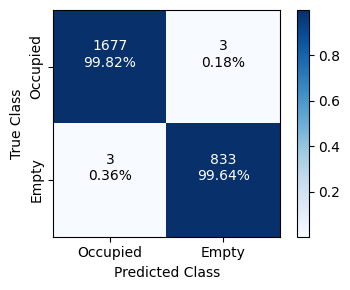

In [ ]:
plot_confusion_matrix(cm_CNR,"CNR")

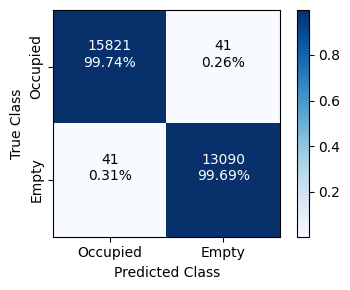

In [ ]:
plot_confusion_matrix(cm_CNR_EXT,"CNR_EXT")

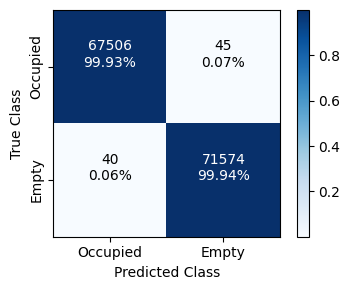

In [ ]:
plot_confusion_matrix(cm_pklot,"PKLot")

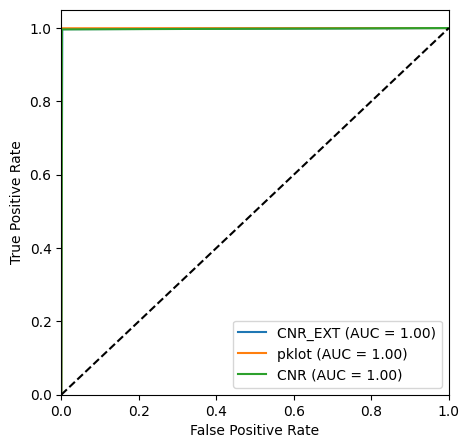

In [ ]:
# ROC curve
fpr_CNR_EXT, tpr_CNR_EXT, _ = roc_curve(y_true_CNR_EXT, y_pred_CNR_EXT)
roc_auc_CNR_EXT = auc(fpr_CNR_EXT, tpr_CNR_EXT)

fpr_pklot, tpr_pklot, _ = roc_curve(y_true_pklot, y_pred_pklot)
roc_auc_pklot = auc(fpr_pklot, tpr_pklot)

fpr_CNR, tpr_CNR, _ = roc_curve(y_true_CNR, y_pred_CNR)
roc_auc_CNR = auc(fpr_CNR, tpr_CNR)

# Plot ROC curve
plt.figure(figsize=(5, 5))
plt.plot(fpr_CNR_EXT, tpr_CNR_EXT, label='CNR_EXT (AUC = {:.2f})'.format(roc_auc_CNR_EXT))
plt.plot(fpr_pklot, tpr_pklot, label='pklot (AUC = {:.2f})'.format(roc_auc_pklot))
plt.plot(fpr_CNR, tpr_CNR, label='CNR (AUC = {:.2f})'.format(roc_auc_CNR))
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
#plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

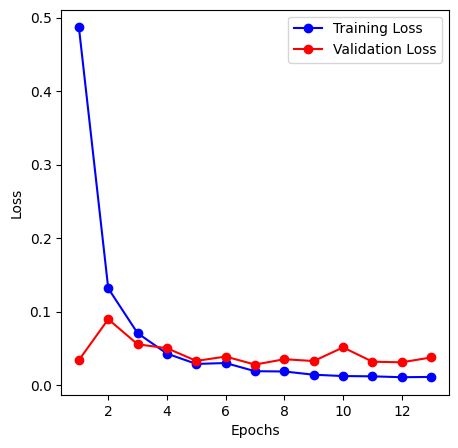

In [ ]:
import matplotlib.pyplot as plt

# Define the data
epochs = range(1, 14)
train_loss = [0.4869, 0.1316, 0.0706, 0.0428, 0.0288, 0.0300, 0.0189, 0.0185, 0.0141, 0.0123, 0.0119, 0.0107, 0.0111]
train_acc = [0.9801, 0.9603, 0.9781, 0.9875, 0.9918, 0.9917, 0.9947, 0.9950, 0.9962, 0.9968, 0.9971, 0.9974, 0.9974]
val_loss = [0.0340, 0.0896, 0.0555, 0.0502, 0.0329, 0.0388, 0.0279, 0.0352, 0.0327, 0.0513, 0.0318, 0.0310, 0.0376]
val_acc = [0.9902, 0.9727, 0.9836, 0.9866, 0.9918, 0.9905, 0.9932, 0.9912, 0.9930, 0.9908, 0.9939, 0.9946, 0.9929]

# Plot the training and validation loss
plt.figure(figsize=(5, 5))
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.title('Training and Validation Loss')
plt.legend()
plt.show()







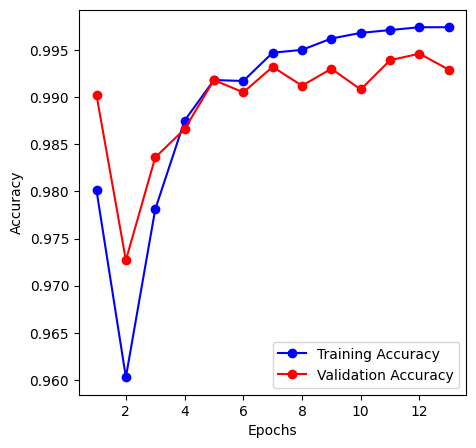

In [ ]:
# Plot the training and validation accuracy
plt.figure(figsize=(5, 5))
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
#plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

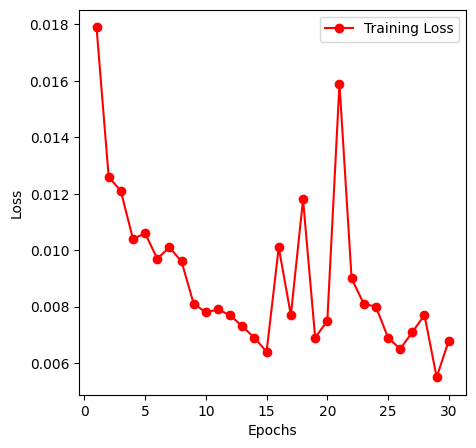

In [ ]:
import matplotlib.pyplot as plt

# Define the data
epochs = range(1, 31)
train_loss =[0.0179, 0.0126, 0.0121, 0.0104, 0.0106, 0.0097, 0.0101, 0.0096, 0.0081, 0.0078,
        0.0079, 0.0077, 0.0073, 0.0069, 0.0064, 0.0101, 0.0077, 0.0118, 0.0069, 0.0075,
        0.0159, 0.0090, 0.0081, 0.0080, 0.0069, 0.0065, 0.0071, 0.0077, 0.0055, 0.0068]

train_acc = [0.9959, 0.9970, 0.9971, 0.9976, 0.9975, 0.9978, 0.9975, 0.9978, 0.9980, 0.9982,
            0.9982, 0.9982, 0.9983, 0.9985, 0.9986, 0.9978, 0.9983, 0.9980, 0.9985, 0.9985,
            0.9963, 0.9979, 0.9982, 0.9983, 0.9984, 0.9986, 0.9985, 0.9984, 0.9988, 0.9986]

# Plot the training loss
plt.figure(figsize=(5, 5))
plt.plot(epochs, train_loss, 'ro-', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.title('Training Loss')
plt.legend()
plt.show()





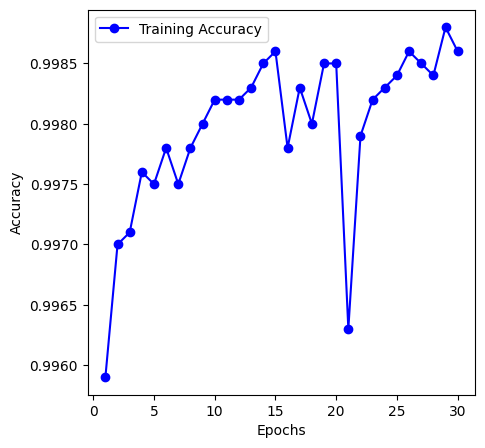

In [ ]:
# Plot the training accuracy
plt.figure(figsize=(5, 5))
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
#plt.title('Training Accuracy')
plt.legend()
plt.show()